# NEXTHIKE-EDA Project By Using Univariate, Bivariate, and Multivariate Statistical Techniques

### Importing libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset of large Retail Transaction

In [12]:
read = pd.read_excel(r'C:\Users\omie\Desktop\Nexthikes\project3\retail_large_dataset.xlsx')

In [13]:
read

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


### Visual Inspection & Schema Check

In [58]:
print("--- Dataset Overview ---")
print(f"Shape: {read.shape}")

--- Dataset Overview ---
Shape: (100000, 18)


In [60]:
#checking data types
read.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  object        
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  object        
 3   city                 100000 non-null  object        
 4   state                100000 non-null  object        
 5   customer_segment     100000 non-null  object        
 6   order_id             100000 non-null  object        
 7   order_date           100000 non-null  datetime64[ns]
 8   product_category     100000 non-null  object        
 9   product_subcategory  100000 non-null  object        
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price    

In [55]:
#checking the first five rows
read.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [56]:
#checking the last five rows
read.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


### Counting missing values for each column

In [40]:
missing_counts = read.isnull().sum()
print(missing_counts)

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64


#### no missing values found

## Checking Summary Statics

In [50]:
# Generate summary statistics table
summary = read.describe()
print(summary)

                 age                  order_date  product_price  \
count  100000.000000                      100000  100000.000000   
mean       41.561830  2024-06-29 02:48:38.304000   30164.526720   
min        18.000000         2023-01-01 00:00:00     500.000000   
25%        30.000000         2023-09-30 00:00:00   15375.000000   
50%        42.000000         2024-06-28 00:00:00   30148.000000   
75%        54.000000         2025-03-30 00:00:00   44957.000000   
max        65.000000         2025-12-30 00:00:00   59998.000000   
std        13.852439                         NaN   17139.679807   

            quantity  discount_percentage    final_price  delivery_days  
count  100000.000000        100000.000000  100000.000000  100000.000000  
mean        2.501790            15.009890   64165.723382       5.505540  
min         1.000000             0.000000     357.000000       1.000000  
25%         1.000000             7.000000   24705.000000       3.000000  
50%         3.000000      

In [61]:
# Checking total count of duplicate rows
num_duplicates = read.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

Total duplicate rows: 0


#### No duplicates found in this data

## Checking Skewness & Kurtosis

In [65]:
# Select numerical columns
num_cols = read.select_dtypes(include=['number'])

# Check Skewness and Kurtosis
print("--- Skewness ---")
print(num_cols.skew())

print("\n--- Kurtosis ---")
print(num_cols.kurtosis())  # Or num_cols.kurt()

--- Skewness ---
age                   -0.004988
product_price          0.003249
quantity              -0.003067
discount_percentage   -0.003597
final_price            0.934747
delivery_days          0.002270
dtype: float64

--- Kurtosis ---
age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64


## Checking Outliers using Boxplots

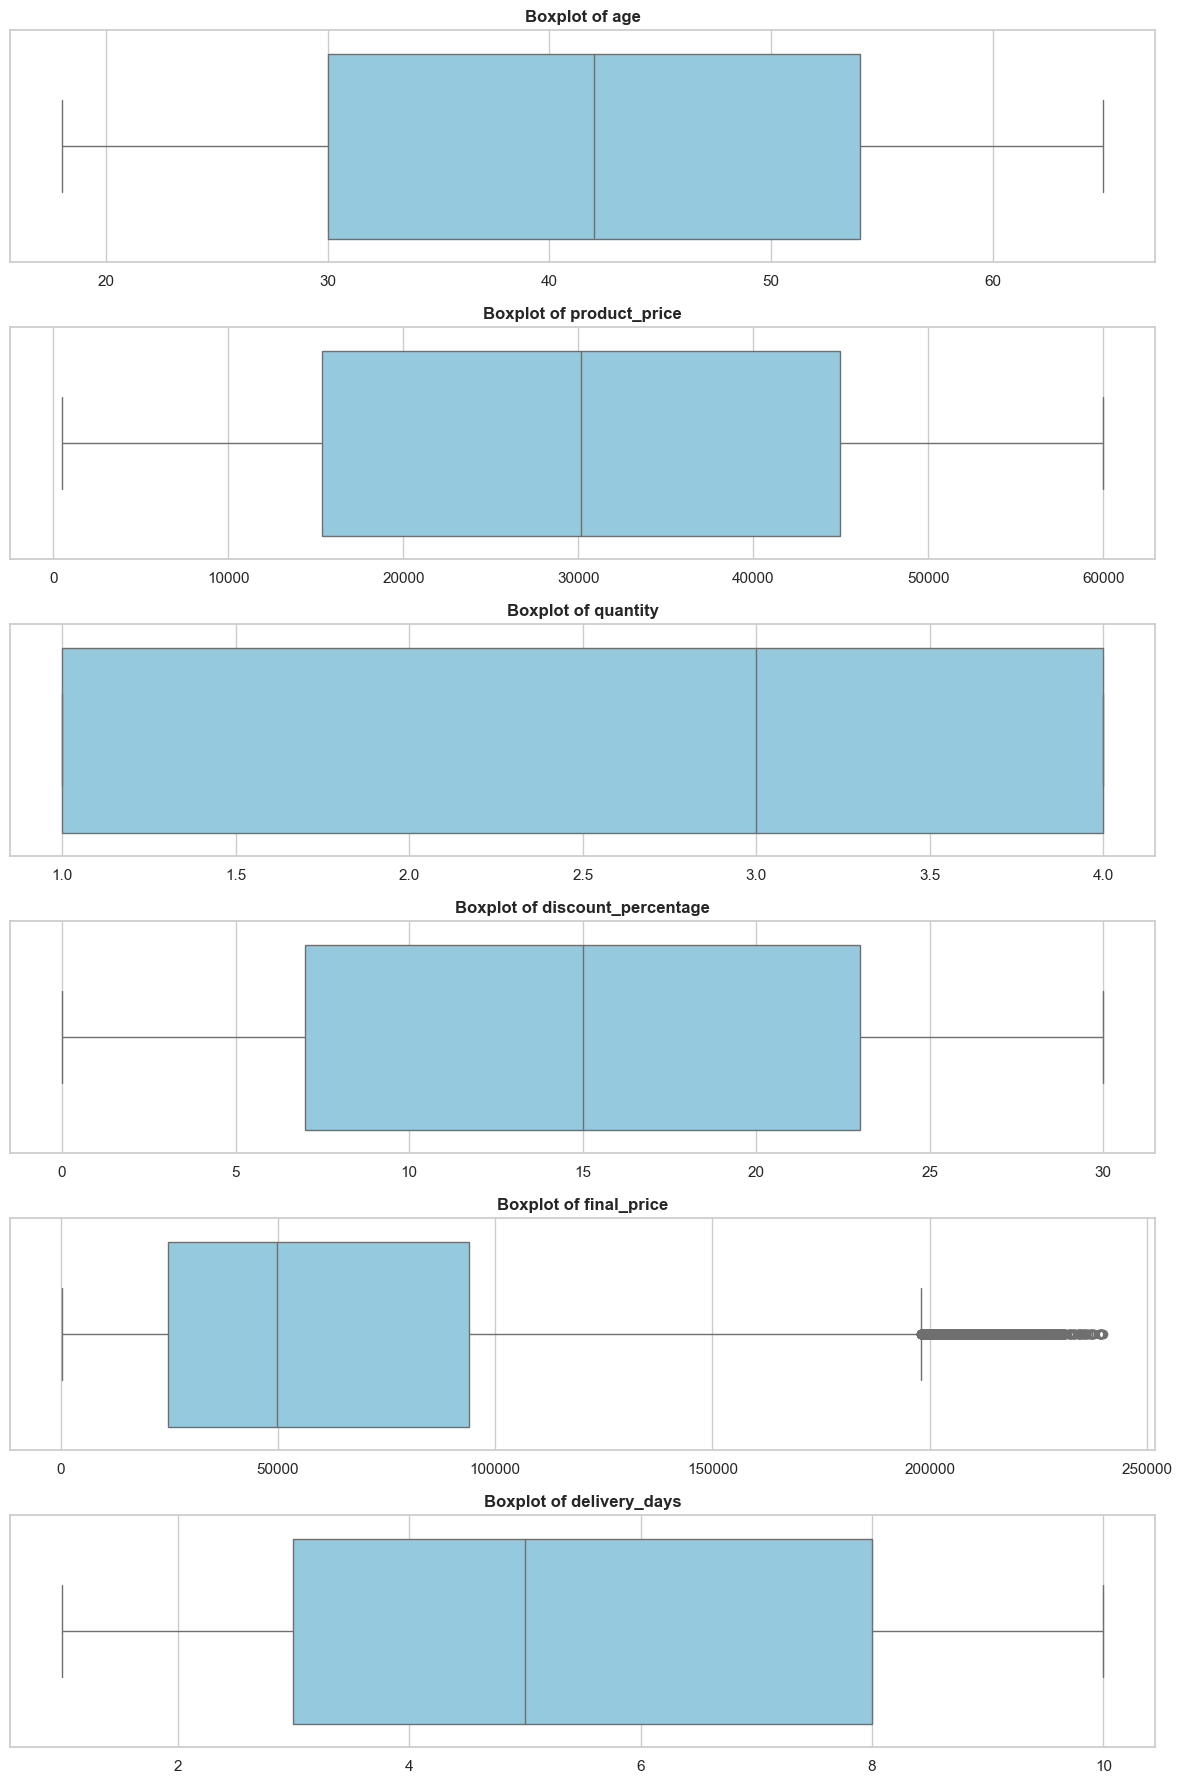

In [67]:
# Select only numerical columns
num_cols = read.select_dtypes(include=['number']).columns

# Set up subplot figure dimensions dynamically based on column count
plt.figure(figsize=(12, 3 * len(num_cols)))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=read[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')

plt.tight_layout()
plt.show()

## UNIVARIATE ANALYSIS


In [6]:
# 2.1 Numerical Variables: Summary Statistics, Skewness, & Kurtosis
num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

print("\n--- Numerical Summary Statistics ---")
summary_stats = read[num_cols].describe().T
summary_stats['skewness'] = read[num_cols].skew()
summary_stats['kurtosis'] = read[num_cols].kurtosis()
print(summary_stats[['mean', '50%', 'std', 'min', 'max', 'skewness', 'kurtosis']])



--- Numerical Summary Statistics ---
                             mean       50%           std    min       max  \
age                     41.561830     42.00     13.852439   18.0      65.0   
product_price        30164.526720  30148.00  17139.679807  500.0   59998.0   
quantity                 2.501790      3.00      1.120058    1.0       4.0   
discount_percentage     15.009890     15.00      8.953296    0.0      30.0   
final_price          64165.723382  49752.39  49969.280150  357.0  239980.0   
delivery_days            5.505540      5.00      2.872868    1.0      10.0   

                     skewness  kurtosis  
age                 -0.004988 -1.201172  
product_price        0.003249 -1.195106  
quantity            -0.003067 -1.364612  
discount_percentage -0.003597 -1.201628  
final_price          0.934747  0.169047  
delivery_days        0.002270 -1.221514  


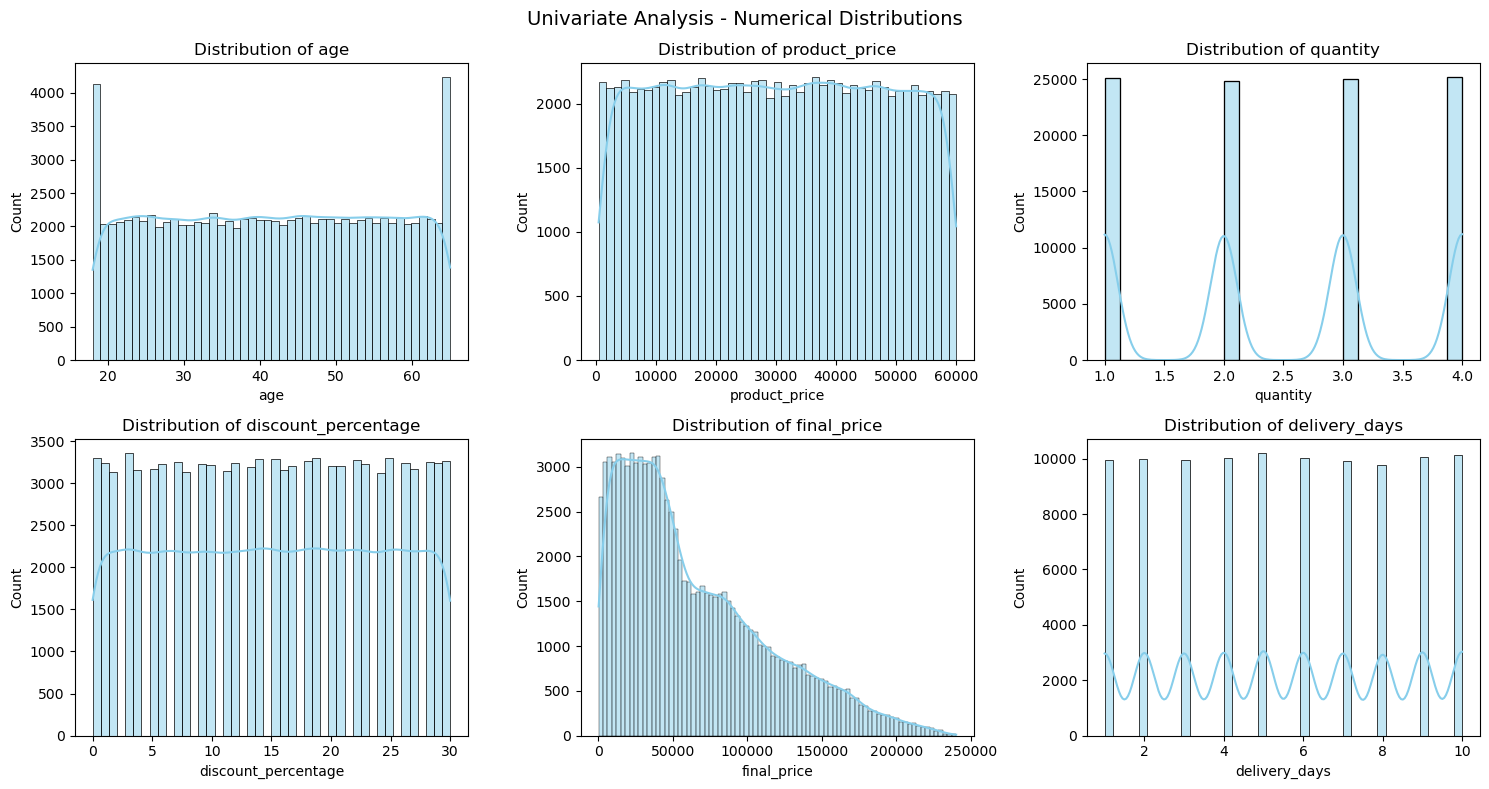

In [9]:
# Histograms / KDE Plots for Numerical Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Univariate Analysis - Numerical Distributions', fontsize=14)

for col, ax in zip(num_cols, axes.flatten()):
    sns.histplot(read[col], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## 2.2 Categorical Variables: Frequency Distributions

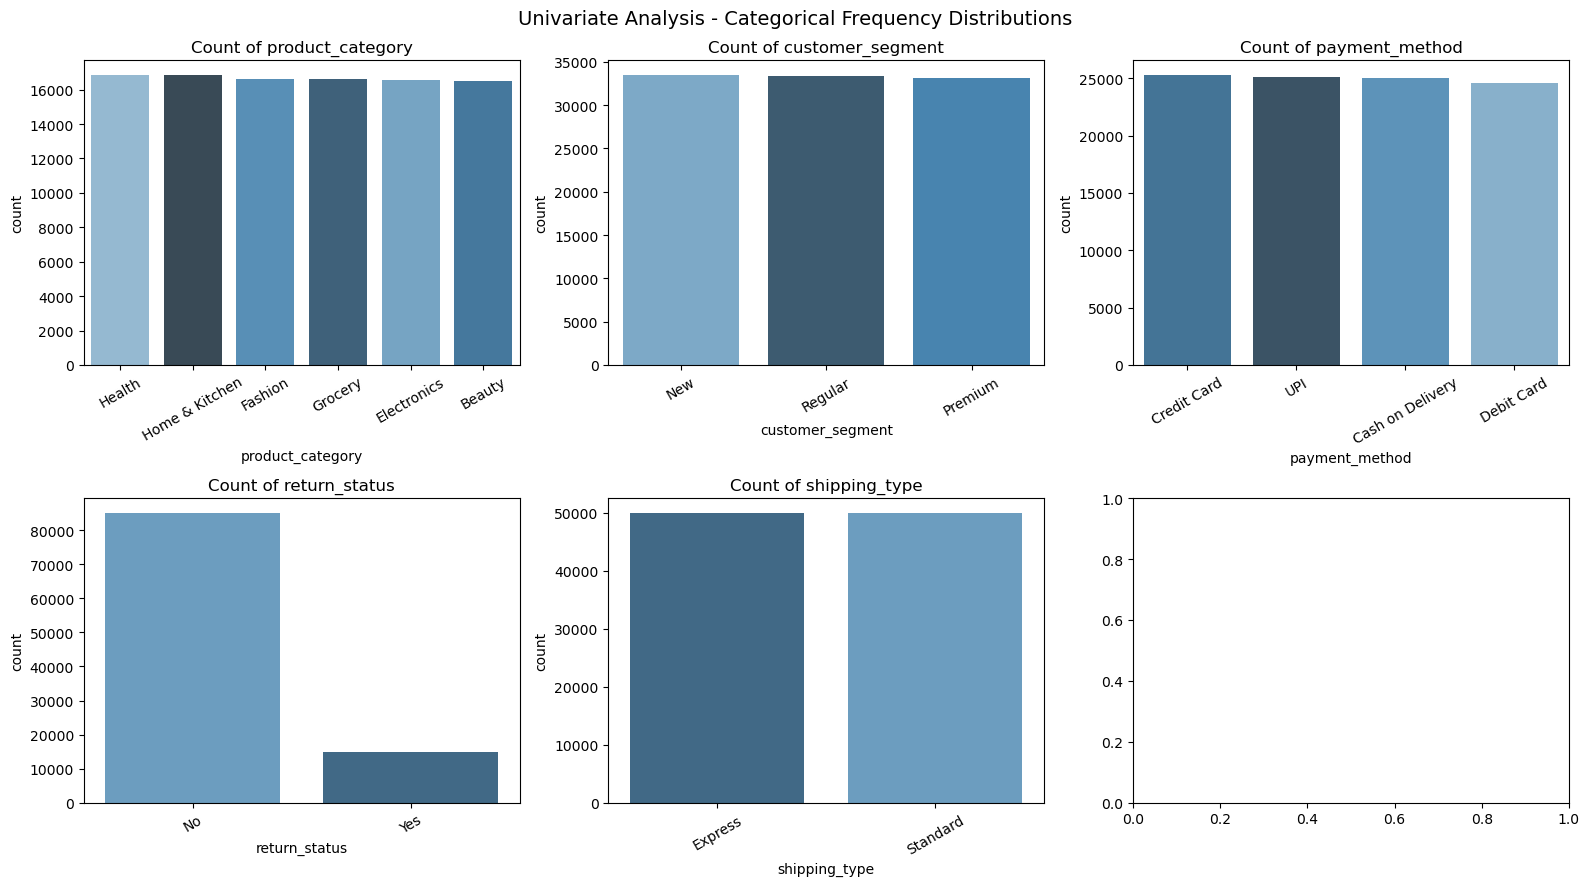

In [22]:
cat_cols = ['product_category', 'customer_segment', 'payment_method', 'return_status', 'shipping_type']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Univariate Analysis - Categorical Frequency Distributions', fontsize=14)

for col, ax in zip(cat_cols, axes.flatten()):
    sns.countplot(data=read, x=col, hue=col, ax=ax, palette='Blues_d',legend=False,order=read[col].value_counts().index)
    ax.set_title(f'Count of {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [23]:
# Print percentage distributions
for col in cat_cols:
    print(f"\n--- {col} Frequency (%) ---")
    print(read[col].value_counts(normalize=True) * 100)


--- product_category Frequency (%) ---
product_category
Health            16.858
Home & Kitchen    16.848
Fashion           16.613
Grocery           16.592
Electronics       16.576
Beauty            16.513
Name: proportion, dtype: float64

--- customer_segment Frequency (%) ---
customer_segment
New        33.488
Regular    33.361
Premium    33.151
Name: proportion, dtype: float64

--- payment_method Frequency (%) ---
payment_method
Credit Card         25.307
UPI                 25.139
Cash on Delivery    24.994
Debit Card          24.560
Name: proportion, dtype: float64

--- return_status Frequency (%) ---
return_status
No     85.189
Yes    14.811
Name: proportion, dtype: float64

--- shipping_type Frequency (%) ---
shipping_type
Express     50.008
Standard    49.992
Name: proportion, dtype: float64


## Boxplots for Outlier Visualizations

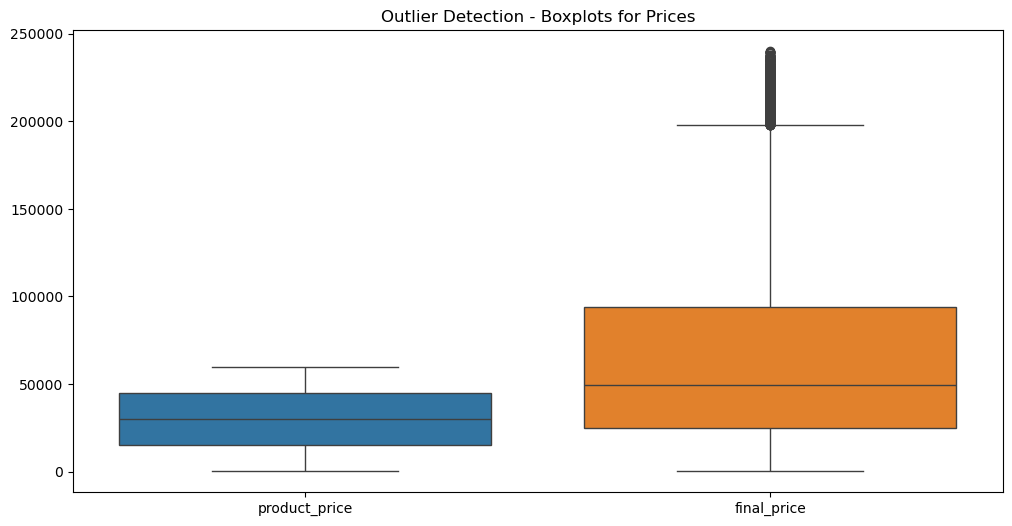

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=read[['product_price', 'final_price']])
plt.title('Outlier Detection - Boxplots for Prices')
plt.show()


In [26]:
# Outlier Count Identification using Interquartile Range (IQR)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

print("\n--- IQR Outlier Counts ---")
for col in ['product_price', 'final_price', 'delivery_days']:
    print(f"{col}: {detect_outliers_iqr(read, col)} outliers")


--- IQR Outlier Counts ---
product_price: 0 outliers
final_price: 1335 outliers
delivery_days: 0 outliers


# BIVARIATE ANALYSIS

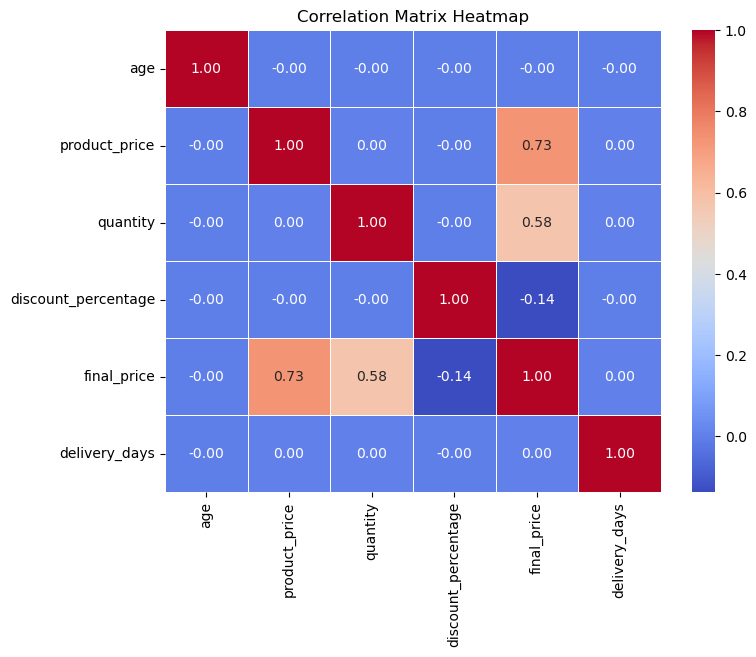

In [27]:
# 4.1 Pearson Correlation Matrix & Heatmap[cite: 1]
plt.figure(figsize=(8, 6))
correlation_matrix = read[num_cols].corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


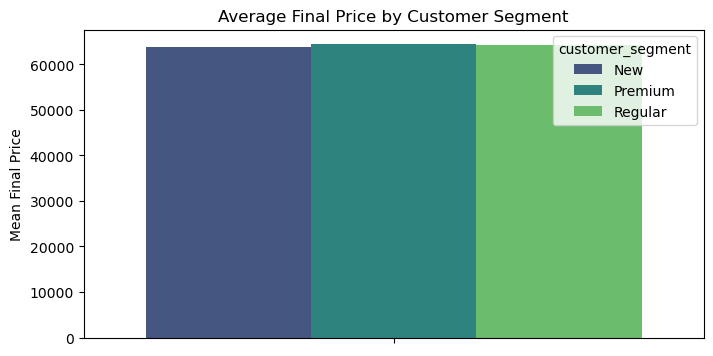

In [32]:
# 4.2 Numerical vs Categorical Relationships[cite: 1]
# Customer Segment vs Average Final Price[cite: 1]
plt.figure(figsize=(8, 4))
sns.barplot(data=read, hue='customer_segment', y='final_price', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Final Price by Customer Segment')
plt.ylabel('Mean Final Price')
plt.show()

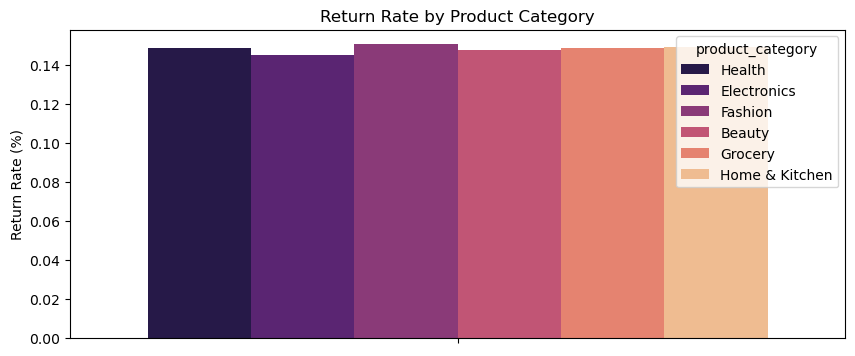

In [39]:
# Product Category vs Return Rate[cite: 1]
read['return_numeric'] = read['return_status'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(10, 4))
sns.barplot(data=read, hue='product_category', y='return_numeric', estimator=np.mean, errorbar=None, palette='magma')
plt.title('Return Rate by Product Category')
plt.ylabel('Return Rate (%)')
plt.tick_params(axis='x', rotation=30)
plt.show()

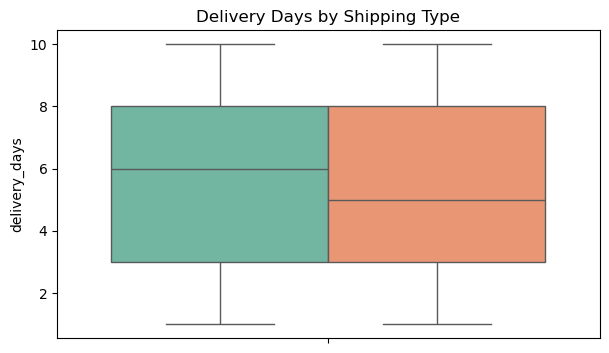

In [15]:
# Shipping Type vs Delivery Days
plt.figure(figsize=(7, 4))
sns.boxplot(data=read, hue='shipping_type', y='delivery_days', palette='Set2', legend = False)
plt.title('Delivery Days by Shipping Type')
plt.show()

# MULTIVARIATE ANALYSIS

In [13]:
# Example 1: Product Category x Discount x Final Price
# Function: pivot_table with custom discount bins
read['discount_bin'] = pd.cut(read['discount_percentage'], bins=[0, 10, 20, 100], labels=['Low', 'Moderate', 'High'])

cat_discount_price = read.pivot_table(
    index='product_category',
    columns='discount_bin',
    values='final_price',
    aggfunc='sum',
    observed=False,
    fill_value=0
)
print("--- 1. Product Category x Discount x Final Price (Total Revenue) ---")
print(cat_discount_price)
print("\n")

--- 1. Product Category x Discount x Final Price (Total Revenue) ---
discount_bin               Low      Moderate          High
product_category                                          
Beauty            3.738416e+08  3.408218e+08  3.008337e+08
Electronics       3.884181e+08  3.386327e+08  2.974169e+08
Fashion           3.781070e+08  3.429030e+08  3.004070e+08
Grocery           3.802797e+08  3.434095e+08  2.976468e+08
Health            3.839459e+08  3.460400e+08  3.032522e+08
Home & Kitchen    3.920769e+08  3.496347e+08  3.080061e+08




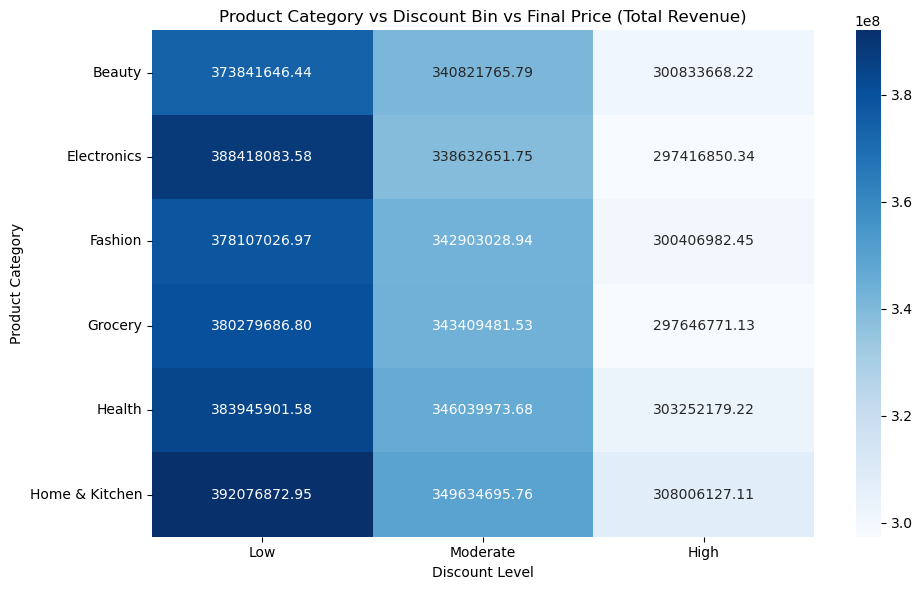

In [14]:
# Visualization: Categorical Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cat_discount_price, annot=True, fmt=".2f", cmap="Blues"
)  # cite: 2
plt.title(
    "Product Category vs Discount Bin vs Final Price (Total Revenue)"
)  # cite: 2
plt.xlabel("Discount Level")  # cite: 2
plt.ylabel("Product Category")  # cite: 2
plt.tight_layout()  # cite: 2
plt.show()

In [20]:
read.columns = read.columns.str.strip()

In [23]:
# Example 2: Customer Segment x Age Group x Spending (Final Price)
customer_segment = read.pivot_table(
    index='customer_segment',
    columns='age',  # Update this to match your actual column name exactly
    values='final_price',
    aggfunc='sum',
    fill_value=0
)

print("--- 2. Customer Segment x Age Group x Spending (Total Final Price) ---")
print(customer_segment)
print("\n")

--- 2. Customer Segment x Age Group x Spending (Total Final Price) ---
age                        18           19           20           21  \
customer_segment                                                       
New               41158156.95  47866833.66  45712736.87  46584814.83   
Premium           45031484.52  42625185.86  41758806.69  39854253.00   
Regular           45728500.29  46837810.79  41268614.70  43294485.72   

age                        22           23           24           25  \
customer_segment                                                       
New               42706197.13  43196392.98  44125076.56  41819407.25   
Premium           42083241.58  48058491.00  45328884.02  46313124.85   
Regular           46462512.05  43459985.96  45937245.87  43519175.25   

age                        26           27  ...           56           57  \
customer_segment                            ...                             
New               47509692.08  40691522.15  ...  4620

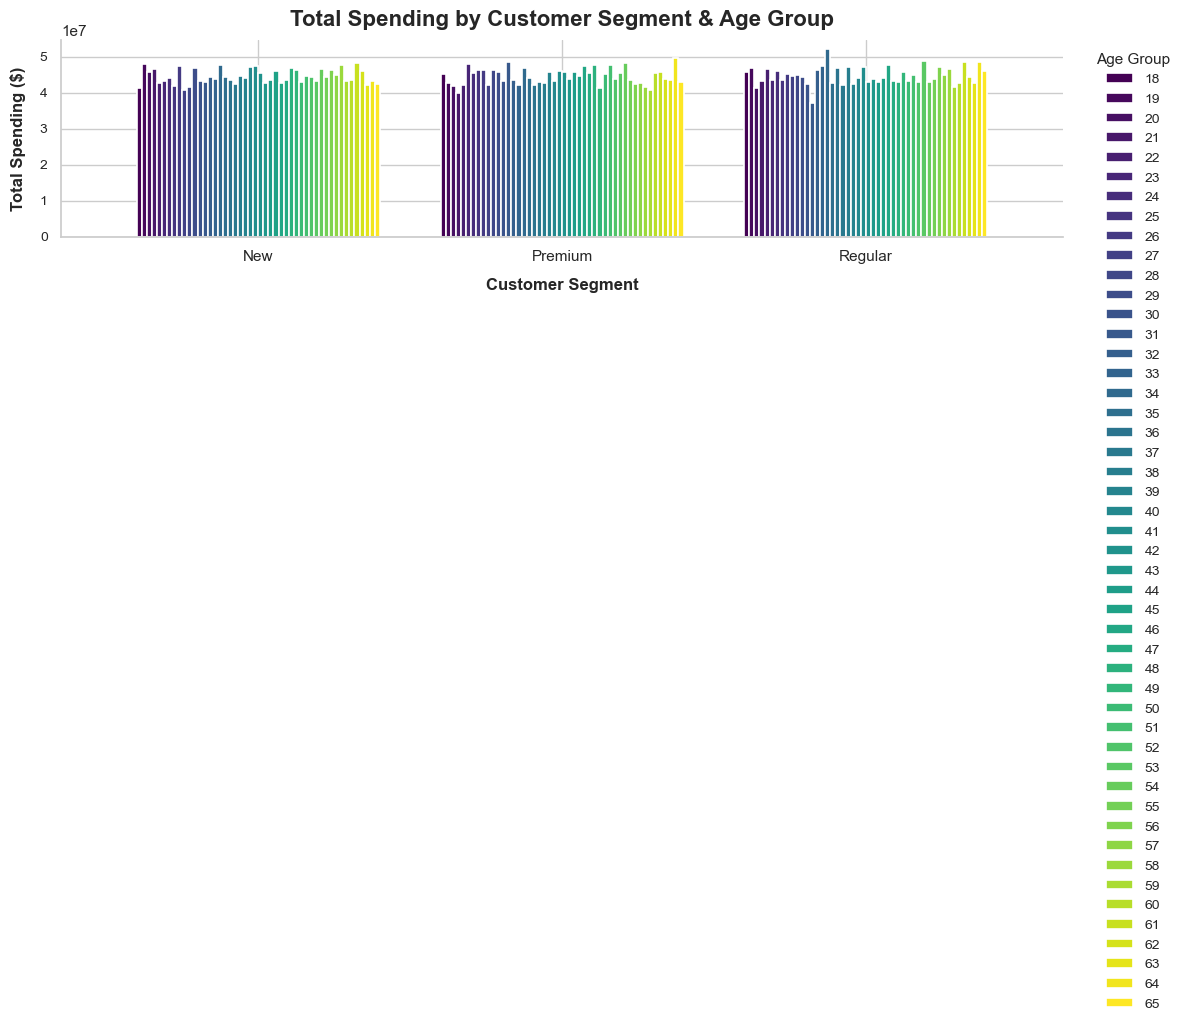

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern theme style
sns.set_theme(style="whitegrid")

# 2. Plot the pivot table using a custom color palette
# Options for color palettes: 'crest', 'viridis', 'Blues', 'Set2', 'muted'
ax = customer_segment.plot(
    kind='bar', 
    figsize=(12, 7), 
    colormap='viridis', 
    edgecolor='white', 
    linewidth=1.2,
    width=0.8
)

# 3. Add title and axis labels with styled fonts
plt.title('Total Spending by Customer Segment & Age Group', fontsize=16, fontweight='bold', pad=10)
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Spending ($)', fontsize=12, fontweight='bold', labelpad=10)

# 4. Format X-axis ticks
plt.xticks(rotation=0, fontsize=11, fontweight='medium')
plt.yticks(fontsize=10)

# 6. Customize the legend position and layout
plt.legend(
    title='Age Group', 
    title_fontsize='11', 
    fontsize='10', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

# 7. Remove unnecessary border spines for a cleaner look
sns.despine(top=True, right=True)

# 8. Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

--- 3. Shipping Type x Return Status vs Average Delivery Days ---
return_status        No       Yes
shipping_type                    
Express        5.495076  5.510661
Standard       5.514729  5.507615




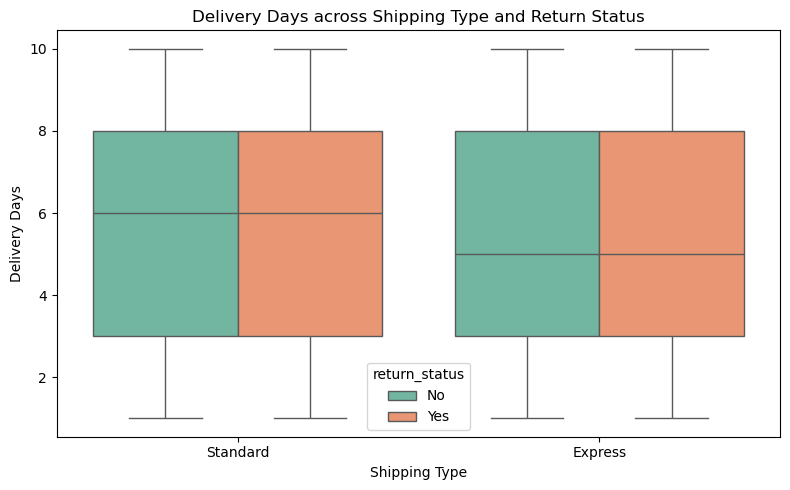

In [26]:
# Example 3: Delivery Days x Shipping Type x Return Status
delivery_shipping_return = read.groupby(['shipping_type', 'return_status'])['delivery_days'].mean().unstack()
print("--- 3. Shipping Type x Return Status vs Average Delivery Days ---")
print(delivery_shipping_return)
print("\n")

# Visualization: Boxplot to examine delivery day distributions by return status & shipping type
plt.figure(figsize=(8, 5))
sns.boxplot(data=read, x='shipping_type', y='delivery_days', hue='return_status', palette='Set2')
plt.title('Delivery Days across Shipping Type and Return Status')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.show()


In [19]:
print(read.columns.tolist())

['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment', 'order_id', 'order_date', 'product_category', 'product_subcategory', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'payment_method', 'shipping_type', 'delivery_days', 'return_status']


## SKEWNESS AND KURTOSIS INTERPRETATION

In [34]:
# Functions: DataFrame.skew() and DataFrame.kurtosis()
skew_vals = read[['product_price', 'final_price']].skew()
kurt_vals = read[['product_price', 'final_price']].kurtosis()

stats_summary = pd.DataFrame({
    'Skewness': skew_vals,
    'Kurtosis': kurt_vals
})

print("--- Skewness and Kurtosis Summary ---")
print(stats_summary)
print("\n")

--- Skewness and Kurtosis Summary ---
               Skewness  Kurtosis
product_price  0.003249 -1.195106
final_price    0.934747  0.169047




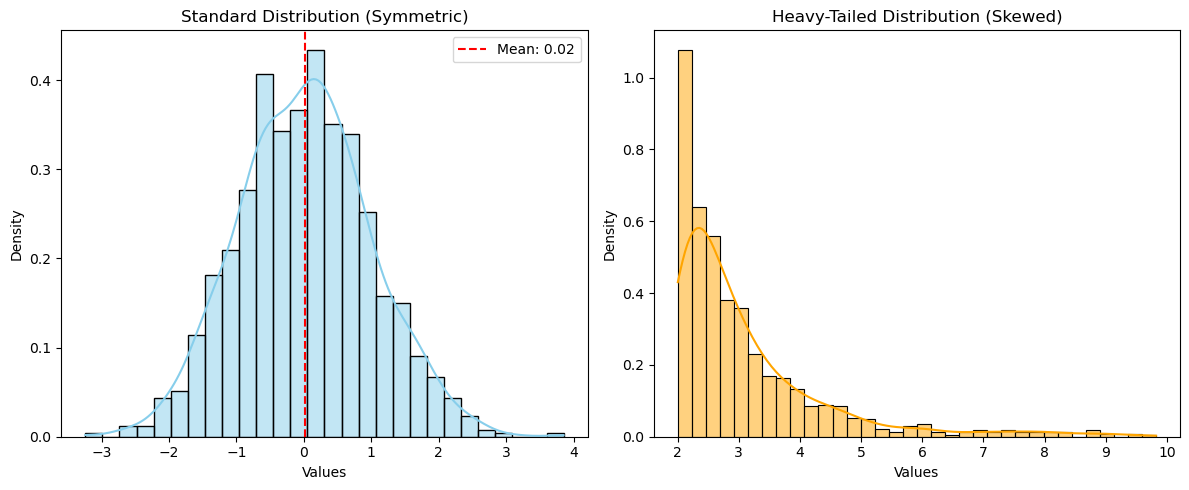

In [9]:

# Filter extreme outliers so the heavy-tailed graph is easy to read
heavy_data_clean = heavy_tailed_data[heavy_tailed_data < 10]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left Plot: Standard Normal Distribution ---
sns.histplot(normal_data, kde=True, stat="density", ax=axes[0], color="skyblue")
axes[0].set_title("Standard Distribution (Symmetric)", fontsize=12)
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Density")

# Mark the Mean
mean_val = np.mean(normal_data)
axes[0].axvline(
    mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}"
)
axes[0].legend()

# --- Right Plot: Heavy-Tailed Distribution ---
sns.histplot(
    heavy_data_clean, kde=True, stat="density", ax=axes[1], color="orange"
)
axes[1].set_title("Heavy-Tailed Distribution (Skewed)", fontsize=12)
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Density")

# Mark Mean and Median to show skewness
mean_heavy = np.mean(heavy_tailed_data)
median_heavy = np.median(heavy_tailed_data)

# 3. Adjust spacing and display
plt.tight_layout()
plt.show()

In [36]:
# Product Price Distribution
sns.histplot(read['product_price'], kde=True, ax=axes[0], color='teal')
axes[0].set_title(f"Product Price (Skew: {skew_vals['product_price']:.2f})")

Text(0.5, 1.0, 'Product Price (Skew: 0.00)')

In [38]:
# Final Price Distribution
sns.histplot(read['final_price'], kde=True, ax=axes[1], color='coral')
axes[1].set_title(f"Final Price (Skew: {skew_vals['final_price']:.2f}, Kurtosis: {kurt_vals['final_price']:.2f})")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# Data Summary & Schema

1. Customer Demographics: customer_id, age, gender, city, state, customer_segment (New, Regular, Premium)
2. Order & Product Info: order_id, order_date, product_category, product_subcategory, product_price, quantity, 
    discount_percentage, final_price
3. Logistics & Payment: payment_method (UPI, Debit Card, Credit Card, Cash on Delivery), shipping_type (Standard, Express),
    delivery_days, return_status

### KEY OBSERVATIONS FROM THE DATASET
* Top Categories: Health, Electronics, Beauty, Fashion, Grocery, and Home & Kitchen.
* Highest Final Price Transaction: Order O50012 (Health - Supplements) at ₹1,48,339.52.
    
### RETURNED ORDERS:
- Order O50001 (Smartphone) by customer C10001 (Pune, Premium).
- Order O50018 (Women Dress) by customer C10018 (Bangalore, New).

### PYTHON LIBRARIES USED
* Pandas
* Matplotlib
* Numpy
* Searborn
  
#### DATA LOADING & SCHEMA SETUP
Uses pd.read_xls() and df.info() to verify column structures, missing values, and data types (18 variables).
#### Univariate Analysis
Statistical Metrics: Calculates mean, median (50%), standard deviation, minimum, maximum, skewness, and kurtosis using .skew() and .kurtosis().
Distributions: Plotting histograms with Kernel Density Estimates (sns.histplot) for numerical variables and frequency bar counts (sns.countplot) for categorical columns.
#### Outlier Detection
Employs visual Boxplots (sns.boxplot) alongside quantitative Interquartile Range (IQR) detection logic to flag potential high-value purchase anomalies.
#### Bivariate Analysis
Pearson Correlation: Computes .corr() 
across numerical attributes and visualizes relationships using sns.heatmap.
Segment Comparisons: Evaluates interaction pairs such as Customer Segment vs. Spending and Shipping Type vs. Delivery Days.
#### Multivariate Analysis
Uses multi-dimensional visualization (hue parameter in Seaborn) to analyze 3-way interactions: Category × Discount × Price, Segment × Age Group × Spending, and Delivery Days × Shipping Type × Return Status.